## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

## Set variables 

In [2]:
# Set the filepaths 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Filepath_bedmachine 
filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'

## Create the mask of ocean coordinates to extract the temperature and salinity profiles 

In [3]:
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)

You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [4]:
# Load in bedmachine (for the mask layer) 
# Values in the bedmachine mask layer 
# 0 == Ocean
# 1 == Ice free land 
# 2 == Grounded ice 
# 3 == Floating ice 
# 4 == Lake vostok 
bmach3 = xr.open_dataset(filepath_bedmachine)
xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)

In [5]:
# For each NEMO cell, calculate the fraction of the cell which is open ocean and ice shelf cavities 
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

save_data = False
if save_data == True:
    fraction_OO = np.ones(coords.nav_lat.shape) * np.nan
    fraction_IC = np.ones(coords.nav_lat.shape) * np.nan
    fraction_GI = np.ones(coords.nav_lat.shape) * np.nan
    fraction_IFL = np.ones(coords.nav_lat.shape) * np.nan
    fraction_LV = np.ones(coords.nav_lat.shape) * np.nan
    for i in range(coords.nav_lat.shape[0]):
        for j in range(coords.nav_lon.shape[1]):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                                       coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            bounds = [np.min(x_square), np.max(x_square), np.min(y_square), np.max(y_square)]
            # Extract the bedmachine mask within the boundaries of the cell 
            bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
            if len(bmach_slice.x) == 0:
                a = np.nan
            else:
                # List corners of rotated rectangle and create polygon
                corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                poly = Polygon(corners)
                # Mask of points inside polygon
                X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                mask = contains(poly, X, Y)
                # Extract bmach_slice inside polygon
                sub_mask = bmach_slice.mask.where(mask == True)
                # Calculate the fraction of points in the mask which are not 100% ocean/cavity
                total_points = np.sum(~np.isnan(sub_mask))
                if total_points > 0:
                    fraction_GI[i,j] = np.sum(sub_mask == 2).values/total_points
                    fraction_IFL[i,j] = np.sum(sub_mask == 1).values/total_points
                    fraction_LV[i,j] = np.sum(sub_mask == 4).values/total_points
                    fraction_OO[i,j] = np.sum(sub_mask == 0).values/total_points
                    fraction_IC[i,j] = np.sum(sub_mask == 3).values/total_points 
        print(i+1, 'out of', coords.nav_lat.shape[0], end = '\r')
    np.savetxt('fraction_IC.csv', fraction_IC)
    np.savetxt('fraction_OO.csv', fraction_OO)
    np.savetxt('fraction_GI.csv', fraction_GI)
    np.savetxt('fraction_IFL.csv', fraction_IFL)
    np.savetxt('fraction_LV.csv', fraction_LV)
else:
    fraction_IC = np.loadtxt('fraction_IC.csv')
    fraction_OO = np.loadtxt('fraction_OO.csv')
    fraction_GI = np.loadtxt('fraction_GI.csv')
    fraction_IFL = np.loadtxt('fraction_IFL.csv')
    fraction_LV = np.loadtxt('fraction_LV.csv')

In [6]:
# Create a mask with all the points which are 100% open ocean or cavity 
fraction_GI[np.isnan(fraction_GI)] = 0
fraction_IFL[np.isnan(fraction_IFL)] = 0
fraction_LV[np.isnan(fraction_LV)] = 0
fraction_OO[np.isnan(fraction_OO)] = 0
fraction_IC[np.isnan(fraction_IC)] = 0

# Regions which are fully ocean or ice shelf (so left to be resolved in the model)
mask_OOIC = fraction_OO+fraction_IC
# Regions which are fully ocean or grounded ice 
mask_OOGI = fraction_OO+fraction_GI+fraction_IFL+fraction_LV

# Sometimes there are really tiny bits of ice shelf and these make the mask a bit silly, so we can remove these 
# Set to 0 if you want to keep everything
fraction_of_edge = 0.0001

# Create a mask 
# 0 ignore these cells
# 1 Fully grounded 
# 2 Contains partial cavities
# 3 Ocean or complete cavity cells
mask_closedcavities = mask_OOIC.copy()
mask_closedcavities[mask_closedcavities > -1] = 0
mask_closedcavities[mask_OOIC > (1-fraction_of_edge)] = 3
mask_closedcavities[mask_OOGI > (1-fraction_of_edge)] = 1
mask_closedcavities[fraction_OO == 1] = 3
mask_closedcavities[(mask_OOIC < (1-fraction_of_edge)) & (mask_OOIC > (0+fraction_of_edge)) & \
                    (mask_OOGI > (0+fraction_of_edge)) & (mask_OOGI < (1-fraction_of_edge))] = 2

plot = False
if plot == True:
    plt.pcolor(mask_closedcavities, cmap = 'Blues')
    plt.colorbar()

In [7]:
# The next step is to extract the edge cells of the ocean 

# Create mask 
mask_NEMO_copy = mask_closedcavities.copy()
#mask_NEMO_copy[mask_NEMO_copy == 0.5] = 0

# Calculate the boundaries of the ocean area 
arr = mask_NEMO_copy
# Create a mask of where the partial ice shelves are (2)
target = arr == 2
# Dilate the targets to mark all neighbors 
neighbors_of_target = binary_dilation(target) 
# Mask of partial ice shelves that are next to ocean/ice shelf
mask =  ((mask_OOIC > (1-fraction_of_edge)) & neighbors_of_target) + \
            ((mask_OOGI > (1-fraction_of_edge)) & neighbors_of_target & (fraction_OO > fraction_of_edge))
# Convert to mask with 1,0 and np.nan
ocean_edge = mask.astype(float)
ocean_edge[ocean_edge == True] = 1
ocean_edge[ocean_edge == False] = 0
ocean_edge[ocean_edge == 0] = np.nan

# And then plot to check 
plot = False
if plot == True:
    fig, ax = plt.subplots(1,1, figsize = (9,5))
    #ax.pcolor(mask_NEMO_copy, cmap = 'Blues_r')
    im = ax.pcolor(ocean_edge, alpha = 0.4, cmap = 'cividis')
    im.set_clim(0,0.5)
    plt.colorbar(im, ax = ax)

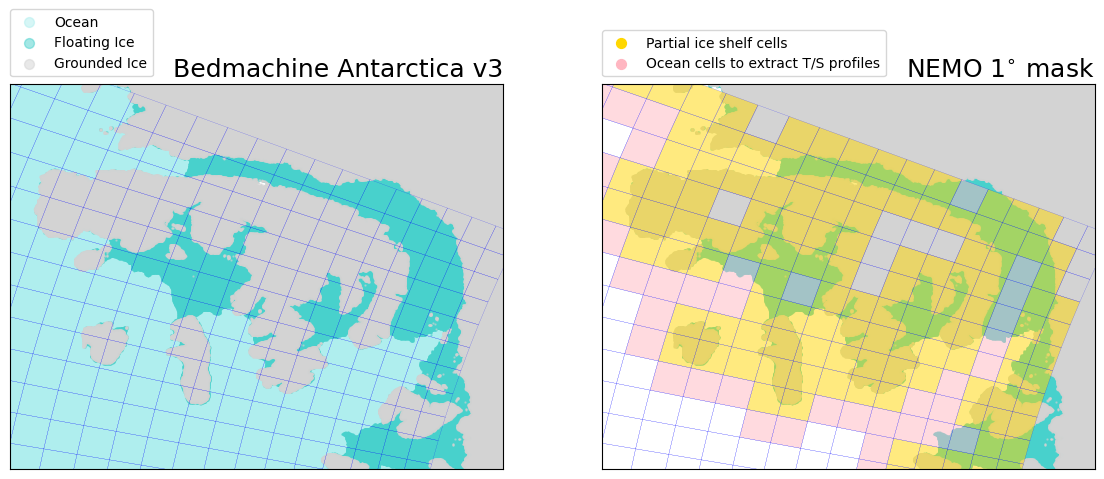

In [20]:
plot_mask = True
if plot_mask == True:
    fig, ax = plt.subplots(1,2, figsize = (14,5))
    
    plotting_area = 'George VI' # 'Ross'
    if plotting_area == 'Thwaites':
        i_low, i_high, j_low, j_high = 45, 65, 170, 190
        xlims = (-1.83e6,-1.48e6)
        ylims = (-0.65e6,-0.25e6)
    elif plotting_area == 'Ross':
        i_low, i_high, j_low, j_high = 6, 23, 11, 130
        xlims = (-0.250e6,-0.0e6)
        ylims = (-0.825e6, -0.575e6)
    elif plotting_area == 'George VI':
        i_low, i_high, j_low, j_high = 60,80, 200, 220
        xlims = (-2.23e6,-1.68e6)
        ylims = (0.4e6,0.90e6)
    else:
        print('HELP: I don\'t know this region')
    
    for i in range(i_low, i_high):
        for j in range(j_low, j_high):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                                       coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                               (x_square[2], y_square[2]), (x_square[3], y_square[3])]
            x_corner = (x_square[0], x_square[1], x_square[2], x_square[3], x_square[0])
            y_corner = (y_square[0], y_square[1], y_square[2], y_square[3], y_square[0])
            poly = Polygon(corners)
            ax[0].plot(x_corner, y_corner, c = 'blue', linewidth = 0.1)
            ax[1].plot(x_corner, y_corner, c = 'blue', linewidth = 0.1)
            if mask_closedcavities[i,j] == 2:
                im = ax[1].fill(x_corner, y_corner, alpha = 0.5, c = 'gold', edgecolor = 'None', zorder = 1)
            if ocean_edge[i,j] == 1:
                im = ax[1].fill(x_corner, y_corner, alpha = 0.5, c = 'lightpink', edgecolor = 'None', zorder = 1)
            
    value = 0
    ax[0].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
                  label = 'Ocean', zorder = 0, alpha = 0.5)
    ax[1].scatter(0,0, color = 'gold', s = 0.5, label = 'Partial ice shelf cells')
    ax[1].scatter(0,0, color = 'lightpink', s = 0.5, label = 'Ocean cells to extract T/S profiles')
    
    label = 'Bedmachine Antarctica v3', 'NEMO 1$^{\\circ}$ mask'
    label2 = 'Grounded Ice', ''
    label3 = 'Floating Ice', ''
    for i in range(2):
        ax[i].set_xlim(xlims)
        ax[i].set_ylim(ylims)
        ax[i].set_xticks([]);
        ax[i].set_yticks([]);
        value = 3
        ax[i].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
                  label = label3[i], zorder = 0, alpha = 0.5)
        value = 2
        ax[i].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
                  label = label2[i], zorder = 0, alpha = 0.5)
        ax[i].annotate(label[i], xy = (0,0), xytext = (1.0,1.02), ha = 'right', xycoords = 'axes fraction', fontsize = 18)
        ax[i].legend(loc = (0,1.02), markerscale = 10);

    #x3, y3 = transformer.transform(masks.lat.values[masks.closed_cavities_nan.values == 1], \
    #                                                   masks.lon.values[masks.closed_cavities_nan.values == 1])
    #ax[1].scatter(x3,y3, s = 2, c = 'grey')
    
    fig.savefig('Mask_method.jpg', bbox_inches = 'tight', dpi = 200)

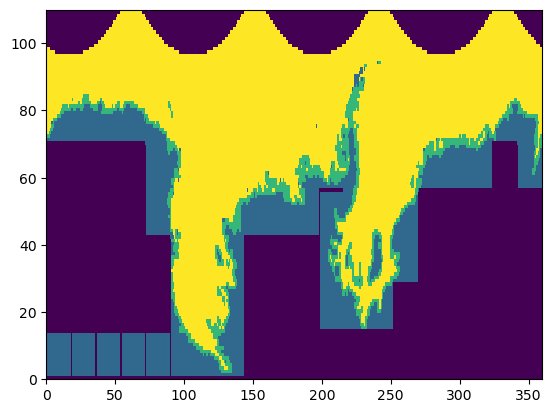

In [10]:
plt.pcolor(mask_closedcavities)

## Extract the temperature and salinity profiles 

In [52]:
# Load in the basins file for 1 degree 
# See supplement at end for how this basins file is made from the 0.25 degree file 

#ds0=xr.open_dataset('../MASKS_PARAM/basin_raster_extrapolate_eANT025.nc')
#basins_NEMO = ds0.basin[::4,::4].values
#ds0.close()

filepath_basins_1 = '../MASKS_PARAM/basin_raster_NEMO1.nc'
ds_basin = xr.open_dataset(filepath_basins_1)
basins_NEMO = ds0.Basins_NEMO_1degree.values
ds_basin.close()

# Some ice shelves which should potentially be joined together into one bigger ice shelf
join_ice_shelves = True
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
#basin_nos = np.unique(basins_NEMO)
basin_nos = np.arange(1,156, dtype = 'float32')

In [53]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)

# For each basin in basin_nos, extract the profiles of the temperature and salinity 
profiles_all = []
i_no_value = []
for kk in range(len(basin_nos)):
    # your code that produces a 1D DataArray
    i = basin_nos[kk]
    mask = (basins_NEMO == i) & (ocean_edge == 1)
    if np.sum(mask) == 0:
        i_no_value.append(int(i))
    #plt.pcolor(mask, cmap = 'Reds')
    masked_depth = gridT2.where(mask == 1)
    profiles = masked_depth.stack(points=("x", "y"))
    profiles = profiles.dropna(dim="points", how="all")
    profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
    # Fill the nan values in the profile
    profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
    # Add a coordinate for kk
    profile_kk = profile_kk.expand_dims(kk=[int(i)-1])
    profiles_all.append(profile_kk)
# Concatenate the profiles along the new dimension
all_profiles = xr.concat(profiles_all, dim="kk")
print('No values for the following {} profiles: {}'.format(len(i_no_value), i_no_value))

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
No values for the following 16 profiles: [17, 20, 29, 37, 52, 56, 69, 79, 89, 96, 100, 109, 112, 128, 131, 134]


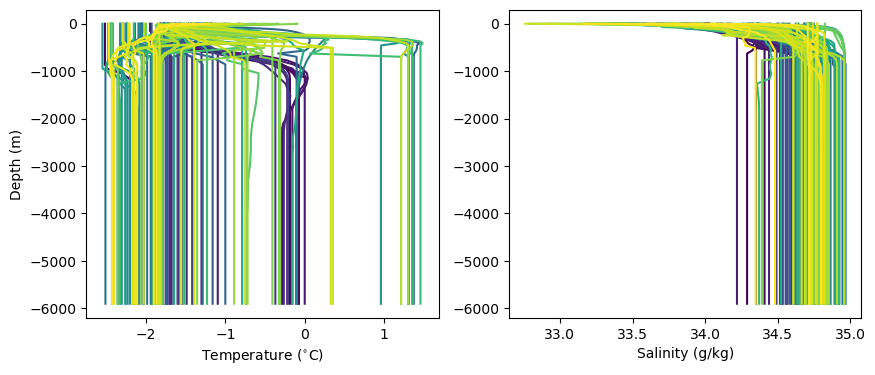

In [54]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');

## Propagate the temperature and salinity profiles onto the target grid 

In [55]:
## Propagate the temperature and salinity profiles onto the target grid 

# Load in the target grid 

nemo_run = 'OPM016'

# Where are the masks stored for the target grid?
filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
# Where do you want processed files to be stored? 
filepath_nn_input = filepath_base + "data/processing_ho/nn_input_"

# Set the filepaths 
# At this stage we need to also have the mask for the target grid 
filepath_mask = filepath_base +  'AIAI_data/Masks/'+nemo_run+'_'+'geometric_masks.nc'
# A geometry file with the required variables for the NN 
filepath_geomvars = filepath_base + 'AIAI_data/Masks/'+nemo_run+'_'+'geom_vars.nc'

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = False)
# We have all the profiles, as a function of kk, and deptht
# all_profiles.thetao
# We have the basins as a function of x_grid and y_grid 
# basins_merged
# which we rename the dimensions to be x and y 
basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int) - 1
# and we have the ice draft depth as a function of x and y 
# geoms.isf_draft

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geom_vars.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geometric_masks.nc


In [56]:
# Extract the relevant values of temperature and salinity 
temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).isel(kk=basins_merged)
sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).isel(kk=basins_merged)

In [57]:
# Convert to float to avoid errors from nans
#temp_xy = temp_xy.astype(float)
#sals_xy = sals_xy.astype(float)
#basins_merged = basins_merged.astype(float)
# Calculate mean and standard deviation by region
# Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
meanT_by_region = temp_xy.groupby(basins_merged).mean()
stdT_by_region  = temp_xy.groupby(basins_merged).std()
meanS_by_region = sals_xy.groupby(basins_merged).mean()
stdS_by_region  = sals_xy.groupby(basins_merged).std()
# and send back to the original grid 
mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
std_S = stdS_by_region.sel(basins_NEMO = basins_merged)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/tmp/ipykernel_1136089/3097248495.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)


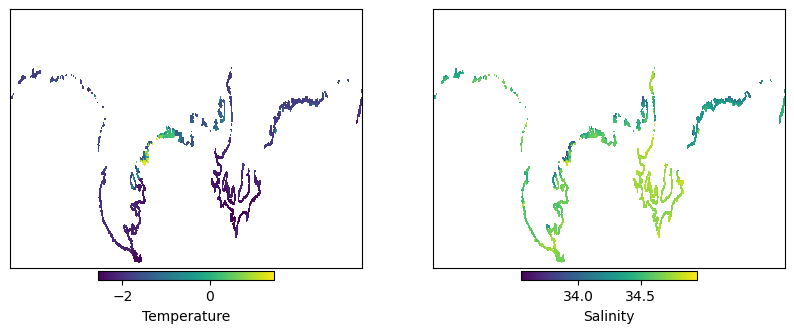

In [58]:
plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])

In [59]:
simulation = 'DUM001'
year_of_interest = '9999'
# Create a netcdf dataset for the temperature and salinity profiles 
ds = xr.Dataset(data_vars=dict(
                                temperature_prop = (["y", "x"], temp_xy.data),
                                salinity_prop    = (["y", "x"], sals_xy.data), 
                              ),
                   coords=dict(
                               lon = (("y", "x"), geoms.lon.data),
                               lat = (("y", "x"), geoms.lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables", 
                               simulation_run = simulation, 
                               year           = year_of_interest),
                              )
# Export to netcdf 
ds.to_netcdf(filepath_nn_input + simulation + '_' + year_of_interest + '.nc')

In [60]:
# There are 134 basins which contain ocean cells adjacent to ice shelves
np.unique((ocean_edge*basins_NEMO)[~np.isnan(ocean_edge*basins_NEMO)])
# But there are 142 basins which contain ice shelves 
np.unique(basins_merged.where(closed_cavs == 1))[~np.isnan(np.unique(basins_merged.where(closed_cavs == 1)))]
# And there's also a mismatch between the numbering systems...

array([  0.,   1.,   2.,   3.,   5.,   6.,   7.,   8.,  10.,  11.,  12.,
        13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,
        24.,  25.,  26.,  27.,  28.,  30.,  31.,  33.,  34.,  35.,  36.,
        37.,  39.,  40.,  41.,  43.,  44.,  45.,  46.,  48.,  49.,  50.,
        51.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,
        64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,
        75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,
        86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  96.,  97.,
        98.,  99., 100., 101., 102., 103., 104., 106., 107., 108., 109.,
       110., 111., 112., 114., 115., 116., 117., 118., 119., 120., 121.,
       123., 124., 125., 126., 127., 128., 129., 131., 132., 133., 134.,
       135., 136., 137., 138., 139., 140., 141., 142., 143., 144., 145.,
       146., 147., 148., 149., 150., 151., 152., 153., 154.])

## Prepare the data to apply the neural network 

In [61]:
# Create the input dataset for the neural network to be applied to
ds = xr.Dataset(data_vars=dict(
                               distances_GL           = (["y", "x"], geoms.distances_GL.data),
                               distances_OO           = (["y", "x"], geoms.distances_OO.data),
                               distances_OC           = (["y", "x"], geoms.distances_OC.data),
                               area                   = (["y", "x"], geoms.areas.data),
                               temperature_prop       = (["y", "x"], temp_xy.data),
                               mean_T                 = (["y", "x"], mean_T.data),
                               std_T                  = (["y", "x"], std_T.data),
                               salinity_prop          = (["y", "x"], sals_xy.data), 
                               mean_S                 = (["y", "x"], mean_S.data),
                               std_S                  = (["y", "x"], std_S.data),
                               corrected_isdraft      = (["y", "x"], geoms.isf_draft.data),
                               bathymetry             = (["y", "x"], geoms.bathymetry.data),
                               slope_is_lon           = (["y", "x"], geoms.slope_isdraft_lon.data),
                               slope_is_lat           = (["y", "x"], geoms.slope_isdraft_lat.data), 
                               slope_ba_lon           = (["y", "x"], geoms.slope_bathy_lon.data),
                               slope_ba_lat           = (["y", "x"], geoms.slope_bathy_lat.data),
                               slope_is_across_front  = (["y", "x"], geoms.slope_is_across_front.data),
                               slope_is_towards_front = (["y", "x"], geoms.slope_is_towards_front.data), 
                               slope_ba_across_front  = (["y", "x"], geoms.slope_ba_across_front.data),
                               slope_ba_towards_front = (["y", "x"], geoms.slope_ba_towards_front.data),
                               basins_NEMO            = (["y", "x"], basins_merged.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), geoms.lon.data),
                               lat = (("y", "x"), geoms.lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables", 
                               simulation_run = simulation, 
                               year           = year_of_interest),
                              )

**Note: You might want to redo the closed cavities mask to correspond better to the NEMO 1 degree grid, but for now sticking with the grid from Nico**

In [62]:
# Rename variables in closed cavity mask 
closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})

# Select only the points in the closed cavity regions
selected = ds.where(closed_cavs == 1).stack(points=("x", "y"))#.dropna("points")
# and convert to a pandas dataframe
selected = selected.reset_coords(drop=False).to_dataframe().reset_index(drop=True).drop(columns=["x", "y"])
# Remove nan values (although still unclear why there are nan values)
selected = selected[~np.isnan(selected.temperature_prop)]

# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'

# Where is the neural network stored?
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

# Apply all 10 neural networks 
melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

## Redistribute melt onto the ocean_edge grid

In [63]:
# Convert array of basin numbers along ocean edge into xarray
basins_edge = xr.DataArray((basins_NEMO*ocean_edge),
                           dims = ("y","x"),
                           coords = dict(
                               lon = (("y", "x"), gridT2.nav_lon.data),
                               lat = (("y", "x"), gridT2.nav_lat.data), 
                           ),
                           name ="basin"
                          )
# Count pixels per basin
pixel_count = basins_edge.groupby(basins_edge).count()
# Convert pandas dataframe of melt by basin to xarray
melt_xr = xr.DataArray(melt_by_basin.melt_Gt, dims = ["basin"], coords = {"basin": melt_by_basin.basin})
# Calculate the melt per pixel 
melt_pixel = melt_xr/pixel_count
# Solve a broadcasting issue 
all_basins = np.unique(basins_NEMO*ocean_edge)
melt_pixel = melt_pixel.reindex(basin=all_basins, fill_value=0)
# Broadcast the melt per pixel to the appropriate cells 
melt_edge = melt_pixel.sel(basin=basins_edge)
melt_edge.name = 'Redistributed melt'
melt_edge = melt_edge.where(melt_edge != 0, np.nan)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


## Look at the resulting melt distribution map for NEMO

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/xarray/core/computation.py:761: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


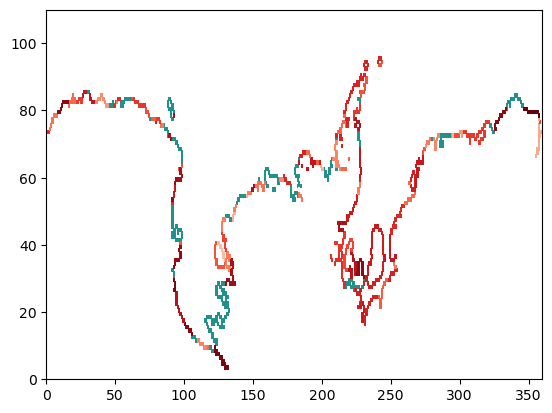

In [67]:
plt.pcolor(np.log10(-melt_edge), cmap = 'Reds_r')
im = plt.pcolor(ocean_edge, zorder = 0)
im.set_clim(0.5,1.5)

## Problem solving

(-90.02817916870117, -55.0)

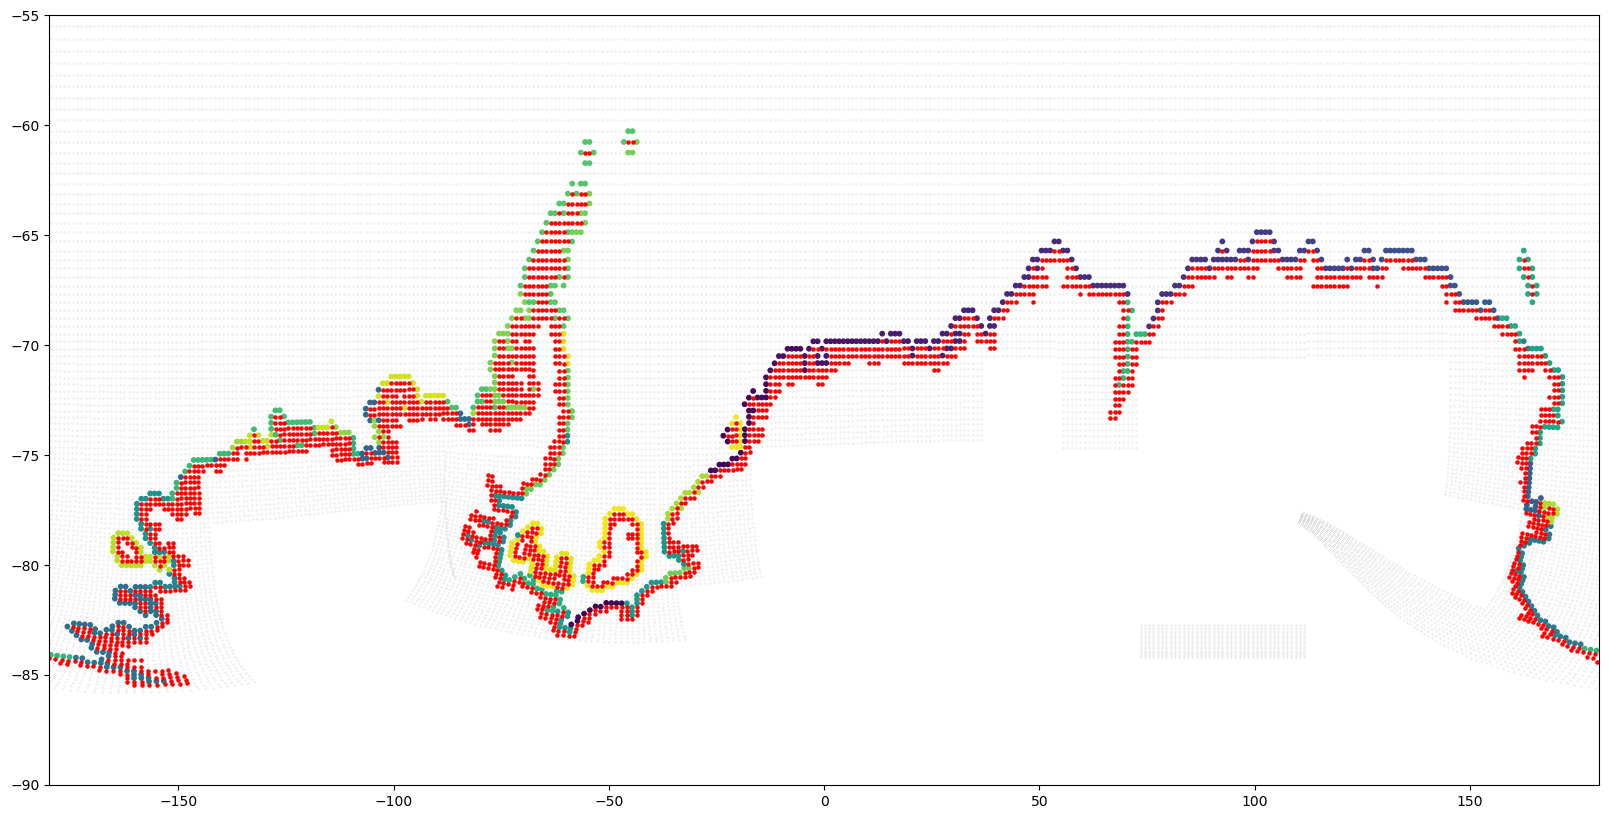

In [24]:
fig, ax = plt.subplots(1,1, figsize = (20,10))
#plt.scatter(melt_edge.lon, melt_edge.lat, c = np.log10(-melt_edge), cmap = 'Reds', s = 10)
plt.scatter(melt_edge.lon, melt_edge.lat, c = 'grey', zorder = 0, s = 0.01)
plt.scatter(melt_edge.lon.values[ocean_edge == 1], melt_edge.lat.values[ocean_edge == 1], \
            c = basins_NEMO[ocean_edge == 1], zorder = 0, s = 10)
plt.scatter(melt_edge.lon.values[mask_closedcavities == 2], \
            melt_edge.lat.values[mask_closedcavities == 2], \
            zorder = 0, s = 5, c = 'red')


#im.set_clim(0.5,1.5)
#plt.colorbar()
ax.set_xlim(-180,180)
ax.set_ylim(None, -55)

## Creating a better version of the basins map for the NEMO 1 degree grid 

In [38]:
from scipy.spatial import cKDTree
import numpy as np

transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x, y = transformer.transform(coords.nav_lat, coords.nav_lon)
x2,y2 = transformer.transform(masks.lat, masks.lon)

# Build KD-tree on source grid
tree = cKDTree(np.column_stack((x2.ravel(), y2.ravel())))
# Query nearest neighbours for target grid
dist, idx = tree.query(np.column_stack((x.ravel(), y.ravel())))
# Map basins

ds0=xr.open_dataset('../MASKS_PARAM/basin_raster_extrapolate_eANT025.nc')
#basins_NEMO = ds0.basin[::4,::4].values
basins_interp = ds0.basin.data.ravel()[idx].reshape(x.shape)
ds0.close()

# Save the basins array as a .nc 
basins_1 = xr.DataArray(basins_interp,
                        dims = ("y", "x"),
                        coords = {"lat": (("y", "x"), gridT2.nav_lat.data),
                                "lon": (("y", "x"), gridT2.nav_lon.data),},
                        name = "Basins_NEMO_1degree"
                       )
filepath_basins_1 = '../MASKS_PARAM/basin_raster_NEMO1.nc'
basins_1.to_netcdf(filepath_basins_1)

